# Notebook 09 — B3.5 Strategic Default Audit Layer

**Objective:** Apply a rule-based audit layer on top of XGBoost predictions to catch strategic defaulters the model may have missed, confirm rule-engineered Tier 5 labels, and de-escalate false positives.

**Input:** `data/processed/08_with_recovery_tiers.csv` (30K × 135)  
**Output:** `data/processed/09_with_audit_tiers.csv` — adds `recovery_tier_final`  

---

## Audit Logic

**Starting point:** `recovery_tier_pred` (XGBoost output, 0-indexed decoded back to 1–5)

**Escalation → Tier 5** (any condition triggers):
- **Rule A — Engineered label override:** `recovery_tier == 5` (rule-based label confirms strategic default — overrides XGBoost miss)
- **Rule B — XGBoost high confidence:** `tier_prob_5 >= 0.15` (model assigns ≥15% probability to Tier 5)
- **Rule C — Fraud signal:** `sp_fraud_rate >= 0.50` AND `bilstm_anomaly_flag=1` AND `default=1`

**De-escalation → Tier 4** (applied after escalation):
- **Rule D — Genuine distress check:** Tier 5 candidate has `distress_avg > 0.65` AND `bilstm_anomaly_flag=0` → likely genuine hardship, not strategic

---

In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


In [2]:
# Cell 2: Configuration

CONFIG = {
    'input_path':    '../../../data/processed/08_with_recovery_tiers.csv',
    'output_path':   '../../../data/processed/09_with_audit_tiers.csv',
    'manifest_path': '../../../models/xgboost/audit_manifest.json',

    # Audit thresholds
    'tier5_prob_threshold':   0.15,   # Rule B: XGBoost Tier 5 probability
    'fraud_rate_threshold':   0.50,   # Rule C: sp_fraud_rate cutoff
    'deesc_distress_threshold': 0.65, # Rule D: distress_avg above this = genuine distress

    'tier_names': {
        1: 'Standard Reminder',
        2: 'Soft Assist',
        3: 'Hardship',
        4: 'Severe Genuine Distress',
        5: 'Strategic Default'
    }
}

print('Configuration loaded.')
print(f'  Rule B threshold (tier_prob_5):  >= {CONFIG["tier5_prob_threshold"]}')
print(f'  Rule C threshold (sp_fraud_rate): >= {CONFIG["fraud_rate_threshold"]}')
print(f'  Rule D threshold (distress_avg):  >  {CONFIG["deesc_distress_threshold"]}')

Configuration loaded.
  Rule B threshold (tier_prob_5):  >= 0.15
  Rule C threshold (sp_fraud_rate): >= 0.5
  Rule D threshold (distress_avg):  >  0.65


In [3]:
# Cell 3: Load Data

df = pd.read_csv(CONFIG['input_path'])
print(f'Loaded: {df.shape}')
print(f'Columns available for audit: recovery_tier, recovery_tier_pred, tier_prob_5, '
      f'bilstm_anomaly_flag, distress_avg, sp_fraud_rate')
print()
print('XGBoost prediction distribution (recovery_tier_pred):')
for t, c in df['recovery_tier_pred'].value_counts().sort_index().items():
    print(f'  Tier {t}: {c:,} ({c/len(df)*100:.1f}%)')

Loaded: (30000, 135)
Columns available for audit: recovery_tier, recovery_tier_pred, tier_prob_5, bilstm_anomaly_flag, distress_avg, sp_fraud_rate

XGBoost prediction distribution (recovery_tier_pred):
  Tier 1: 10,163 (33.9%)
  Tier 2: 12,523 (41.7%)
  Tier 3: 3,218 (10.7%)
  Tier 4: 3,877 (12.9%)
  Tier 5: 219 (0.7%)


In [4]:
# Cell 4: Apply Audit Rules

default_col = 'default payment next month'

# --- Escalation flags ---
# Rule A: engineered label says Tier 5 (rule-based ground truth)
rule_a = (df['recovery_tier'] == 5)

# Rule B: XGBoost assigns high probability to Tier 5
rule_b = (df['tier_prob_5'] >= CONFIG['tier5_prob_threshold'])

# Rule C: strong fraud signal
rule_c = (
    (df['sp_fraud_rate'] >= CONFIG['fraud_rate_threshold']) &
    (df['bilstm_anomaly_flag'] == 1) &
    (df[default_col] == 1)
)

escalate = rule_a | rule_b | rule_c

# Start from XGBoost predictions
df['recovery_tier_final'] = df['recovery_tier_pred']

# Apply escalation
df.loc[escalate, 'recovery_tier_final'] = 5

# --- De-escalation (Rule D) ---
# Flagged as Tier 5 but genuinely distressed (not strategic) + no payment anomaly
rule_d = (
    (df['recovery_tier_final'] == 5) &
    (df['distress_avg'] > CONFIG['deesc_distress_threshold']) &
    (df['bilstm_anomaly_flag'] == 0)
)
df.loc[rule_d, 'recovery_tier_final'] = 4

# --- Audit trail flags ---
df['audit_escalated']   = (escalate & (df['recovery_tier_pred'] != 5)).astype(int)
df['audit_deescalated'] = rule_d.astype(int)
df['audit_rule_a']      = rule_a.astype(int)
df['audit_rule_b']      = rule_b.astype(int)
df['audit_rule_c']      = rule_c.astype(int)
df['audit_rule_d']      = rule_d.astype(int)

print('Audit rules applied.')
print(f'  Rule A (engineered label Tier 5):        {rule_a.sum():>5,} customers')
print(f'  Rule B (tier_prob_5 >= {CONFIG["tier5_prob_threshold"]}):         {rule_b.sum():>5,} customers')
print(f'  Rule C (fraud + anomaly + default):      {rule_c.sum():>5,} customers')
print(f'  Any escalation triggered:                {escalate.sum():>5,} customers')
print(f'  Rule D de-escalations (Tier 5 → Tier 4): {rule_d.sum():>5,} customers')
print()
print(f'Net new escalations to Tier 5: {df["audit_escalated"].sum():,}')
print(f'Net de-escalations from Tier 5: {df["audit_deescalated"].sum():,}')

Audit rules applied.
  Rule A (engineered label Tier 5):          180 customers
  Rule B (tier_prob_5 >= 0.15):           473 customers
  Rule C (fraud + anomaly + default):         11 customers
  Any escalation triggered:                  485 customers
  Rule D de-escalations (Tier 5 → Tier 4):     0 customers

Net new escalations to Tier 5: 266
Net de-escalations from Tier 5: 0


In [5]:
# Cell 5: Tier Comparison — Before vs After Audit

print('=' * 60)
print(f'{"Tier":<6} {"Label":<26} {"XGBoost":>8} {"After Audit":>12} {"Delta":>8}')
print('-' * 60)
for t in range(1, 6):
    before = (df['recovery_tier_pred'] == t).sum()
    after  = (df['recovery_tier_final'] == t).sum()
    delta  = after - before
    sign   = '+' if delta >= 0 else ''
    print(f'Tier {t}  {CONFIG["tier_names"][t]:<26} {before:>8,} {after:>12,} {sign+str(delta):>8}')
print('=' * 60)

print()
print('Customers where audit changed the tier:')
changed = df['recovery_tier_pred'] != df['recovery_tier_final']
print(f'  Total changed: {changed.sum():,} ({changed.mean()*100:.2f}% of customers)')

print()
print('Agreement between engineered labels and final audit tier:')
agree = (df['recovery_tier'] == df['recovery_tier_final']).mean()
print(f'  recovery_tier vs recovery_tier_final: {agree*100:.2f}% agreement')

Tier   Label                       XGBoost  After Audit    Delta
------------------------------------------------------------
Tier 1  Standard Reminder            10,163       10,014     -149
Tier 2  Soft Assist                  12,523       12,432      -91
Tier 3  Hardship                      3,218        3,209       -9
Tier 4  Severe Genuine Distress       3,877        3,860      -17
Tier 5  Strategic Default               219          485     +266

Customers where audit changed the tier:
  Total changed: 266 (0.89% of customers)

Agreement between engineered labels and final audit tier:
  recovery_tier vs recovery_tier_final: 96.60% agreement


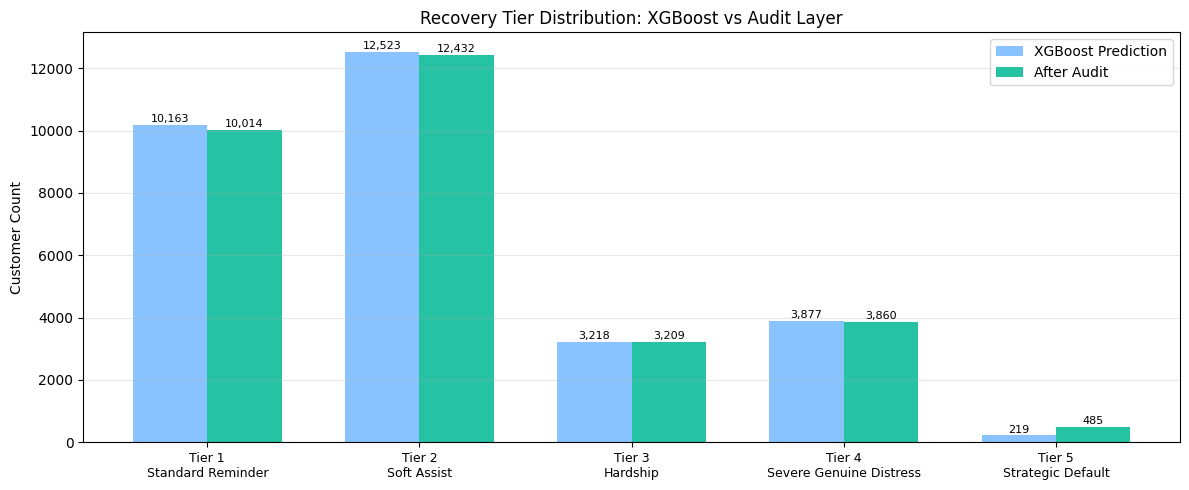

In [6]:
# Cell 6: Visualisation — Tier Distribution Before vs After

tier_labels = [CONFIG['tier_names'][i] for i in range(1, 6)]
before_counts = [( df['recovery_tier_pred']  == t).sum() for t in range(1, 6)]
after_counts  = [(df['recovery_tier_final'] == t).sum() for t in range(1, 6)]

x     = np.arange(5)
width = 0.35
colors = ['#74b9ff', '#00b894']

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, before_counts, width, label='XGBoost Prediction', color=colors[0], alpha=0.85)
bars2 = ax.bar(x + width/2, after_counts,  width, label='After Audit',        color=colors[1], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Tier {i+1}\n{tier_labels[i]}' for i in range(5)], fontsize=9)
ax.set_ylabel('Customer Count')
ax.set_title('Recovery Tier Distribution: XGBoost vs Audit Layer')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../../../models/xgboost/audit_tier_comparison.png', dpi=150)
plt.show()

In [7]:
# Cell 7: Save Output + Manifest

df.to_csv(CONFIG['output_path'], index=False)
print(f'Output saved: {CONFIG["output_path"]}')
print(f'Shape: {df.shape}')
print(f'New columns: recovery_tier_final, audit_escalated, audit_deescalated, audit_rule_a/b/c/d')

final_dist = df['recovery_tier_final'].value_counts().sort_index().to_dict()

manifest = {
    'notebook': '09_audit_layer',
    'input_file':  CONFIG['input_path'],
    'output_file': CONFIG['output_path'],
    'audit_rules': {
        'A': 'recovery_tier == 5 (engineered label override)',
        'B': f'tier_prob_5 >= {CONFIG["tier5_prob_threshold"]} (XGBoost high confidence)',
        'C': f'sp_fraud_rate >= {CONFIG["fraud_rate_threshold"]} AND bilstm_anomaly_flag=1 AND default=1',
        'D': f'De-escalation: Tier5 AND distress_avg > {CONFIG["deesc_distress_threshold"]} AND bilstm_anomaly_flag=0 → Tier4'
    },
    'audit_summary': {
        'rule_a_triggered': int(rule_a.sum()),
        'rule_b_triggered': int(rule_b.sum()),
        'rule_c_triggered': int(rule_c.sum()),
        'total_escalated':  int(df['audit_escalated'].sum()),
        'total_deescalated': int(df['audit_deescalated'].sum()),
        'pct_changed': round(float(changed.mean() * 100), 3),
    },
    'final_tier_distribution': {f'tier_{k}': v for k, v in final_dist.items()},
}

with open(CONFIG['manifest_path'], 'w') as f:
    json.dump(manifest, f, indent=2)
print(f'Manifest saved: {CONFIG["manifest_path"]}')

Output saved: ../../../data/processed/09_with_audit_tiers.csv
Shape: (30000, 142)
New columns: recovery_tier_final, audit_escalated, audit_deescalated, audit_rule_a/b/c/d
Manifest saved: ../../../models/xgboost/audit_manifest.json


In [8]:
# Cell 8: Sanity Check

print('SANITY CHECK')
print('=' * 55)

df_check = pd.read_csv(CONFIG['output_path'])

print(f'1. Output readable:                  OK — {df_check.shape}')
print(f'2. recovery_tier_final present:      {"OK" if "recovery_tier_final" in df_check.columns else "FAIL"}')
print(f'3. Tier values in [1,5]:             {"OK" if df_check["recovery_tier_final"].between(1,5).all() else "FAIL"}')
print(f'4. All 5 tiers present:              {"OK" if df_check["recovery_tier_final"].nunique()==5 else "FAIL"}')
print(f'5. No NaN in final tier:             {"OK" if df_check["recovery_tier_final"].isna().sum()==0 else "FAIL"}')
print(f'6. Audit trail cols present:         {"OK" if all(c in df_check.columns for c in ["audit_rule_a","audit_rule_b","audit_rule_c","audit_rule_d"]) else "FAIL"}')
print(f'7. customer_id present:              {"OK" if "customer_id" in df_check.columns else "FAIL"}')

print()
print('Final tier distribution (recovery_tier_final):')
for t, c in df_check['recovery_tier_final'].value_counts().sort_index().items():
    print(f'  Tier {t} ({CONFIG["tier_names"][t]:>26s}): {c:,} ({c/len(df_check)*100:.1f}%)')

print()
print('=' * 55)
print('B3.5 Audit Layer COMPLETE')
print('Pipeline output: recovery_tier_final is the production label.')
print('=' * 55)

SANITY CHECK
1. Output readable:                  OK — (30000, 142)
2. recovery_tier_final present:      OK
3. Tier values in [1,5]:             OK
4. All 5 tiers present:              OK
5. No NaN in final tier:             OK
6. Audit trail cols present:         OK
7. customer_id present:              OK

Final tier distribution (recovery_tier_final):
  Tier 1 (         Standard Reminder): 10,014 (33.4%)
  Tier 2 (               Soft Assist): 12,432 (41.4%)
  Tier 3 (                  Hardship): 3,209 (10.7%)
  Tier 4 (   Severe Genuine Distress): 3,860 (12.9%)
  Tier 5 (         Strategic Default): 485 (1.6%)

B3.5 Audit Layer COMPLETE
Pipeline output: recovery_tier_final is the production label.
